# Experiment 1 — Fully Frozen ResNet18 Baseline for CDT Classification

**Project:** Deep Learning-Based Approach for Cognitive Decline Screening Through Clock Drawing Test Image Analysis  
**Experiment:** Experiment 1 — Fully Frozen Baseline  
**Model Setup:** ImageNet-pretrained ResNet18 backbone with all backbone layers frozen  
**Output Classes:** `Impaired`, `Mild`, `Normal`

<br>

---

<br>

## Experiment Purpose

Experiment 1 establishes the baseline performance of ResNet18 transfer learning for Clock Drawing Test image classification.

The ImageNet-pretrained ResNet18 backbone is used as a fixed feature extractor, while only the custom classifier head is trained on the CDT dataset. This setup evaluates how well pretrained visual features perform before applying partial or full fine-tuning.

<br>

---

<br>

## Main Difference from Experiments 2 and 3

| Experiment | Backbone Setup | Imbalance Handling | Purpose |
|---|---|---|---|
| Experiment 1 | Fully frozen backbone | Standard augmentation | Baseline feature extraction |
| Experiment 2 | Last 30% unfrozen | Standard augmentation | Partial adaptation |
| Experiment 3 | 100% trainable backbone | Oversampling + class weights | Full adaptation with minority-class support |

<br>

> **Research note:** Experiment 1 serves as the control baseline for comparing whether deeper fine-tuning strategies improve CDT classification performance.

---
# Section 1 — Environment Setup and Library Imports

The required libraries are prepared for model loading, dataset processing, training, visualization, and evaluation.

In [ ]:
# ============================================================
# SECTION 1: ENVIRONMENT SETUP AND LIBRARY IMPORTS
# ============================================================

!pip install -q keras-hub keras

import os
import random
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf
import keras
import keras_hub

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support
)

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Keras version      :", keras.__version__)
print("TensorFlow version :", tf.__version__)

Environment ready.
Keras version      : 3.13.2
TensorFlow version : 2.20.0


## Section 1.1 — Experiment Configuration

The main experiment settings are defined in one place, including image size, batch size, dataset path, and model-saving paths.

In [ ]:
# ============================================================
# SECTION 1.1: GLOBAL CONFIGURATION
# ============================================================

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)

FOLDER_PATH = "/content/drive/MyDrive/Colab Notebooks/Experiment_data_3class"

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/models"

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "exp1_frozen_resnet18_best.keras")
FINAL_MODEL_PATH = os.path.join(SAVE_DIR, "exp1_frozen_resnet18_final.keras")
SUMMARY_CSV_PATH = os.path.join(SAVE_DIR, "exp1_summary_metrics.csv")
PER_CLASS_CSV_PATH = os.path.join(SAVE_DIR, "exp1_per_class_metrics.csv")

print("Dataset path      :", FOLDER_PATH)
print("Best model path   :", BEST_MODEL_PATH)
print("Final model path  :", FINAL_MODEL_PATH)

Configuration loaded.
Dataset path      : /content/drive/MyDrive/Colab Notebooks/Experiment_data_3class
Best model path   : /content/drive/MyDrive/Colab Notebooks/models/exp1_frozen_resnet18_best.keras
Final model path  : /content/drive/MyDrive/Colab Notebooks/models/exp1_frozen_resnet18_final.keras


---
# Section 2 — Load the ImageNet-Pretrained ResNet18 Backbone

An ImageNet-pretrained ResNet18 backbone is initialized through KerasHub. This backbone provides the visual feature extractor used in the baseline model.

<br>

> **Research note:** In Experiment 1, the pretrained backbone remains frozen so that only the classifier head learns from the CDT dataset.

In [ ]:
# ============================================================
# SECTION 2: LOAD PRETRAINED RESNET18 BACKBONE
# ============================================================

backbone = keras_hub.models.ResNetBackbone.from_preset("resnet_18_imagenet")

print("ResNet18 backbone loaded successfully.")
print("Expected input shape : (None, 224, 224, 3)")
print("Total backbone layers:", len(backbone.layers))

ResNet18 backbone loaded successfully.
Expected input shape : (None, 224, 224, 3)
Total backbone layers: 72


## Section 2.1 — Inspect the Backbone Before Freezing

The backbone architecture is reviewed before applying the frozen-baseline setup. Trainable-layer verification is performed later after the backbone is explicitly frozen.

In [ ]:
# ============================================================
# SECTION 2.1: BACKBONE INSPECTION
# ============================================================

backbone.summary()

print("\nLast 10 backbone layers:")
for layer in backbone.layers[-10:]:
    print(f"{layer.name:<45} | {layer.__class__.__name__:<25} | trainable: {layer.trainable}")

Model: "res_net_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,408 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_co… │ (None, None,      │     36,864 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_bn  │ (None, None,      │        256 │ stack0_block0_1_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_re… │ (None, None,      │          0 │ stack0_block0_1_… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_co… │ (None, None,      │     36,864 │ stack0_block0_1_… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_bn  │ (None, None,      │        256 │ stack0_block0_2_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_add   │ (None, None,      │          0 │ pool1_pool[0][0], │
│ (Add)               │ None, 64)         │            │ stack0_block0_2_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_out   │ (None, None,      │          0 │ stack0_block0_ad… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block1_1_co… │ (None, None,      │     36,864 │ stack0_block0_ou… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block1_1_bn  │ (None, None,      │        256 │ stack0_block1_1_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block1_1_re… │ (None, None,      │          0 │ stack0_block1_1_

 Total params: 11,186,112 (42.67 MB)

 Trainable params: 11,176,512 (42.64 MB)

 Non-trainable params: 9,600 (37.50 KB)


Last 10 backbone layers:
stack3_block0_2_bn                            | BatchNormalization        | trainable: True
stack3_block0_add                             | Add                       | trainable: True
stack3_block0_out                             | Activation                | trainable: True
stack3_block1_1_conv                          | Conv2D                    | trainable: True
stack3_block1_1_bn                            | BatchNormalization        | trainable: True
stack3_block1_1_relu                          | Activation                | trainable: True
stack3_block1_2_conv                          | Conv2D                    | trainable: True
stack3_block1_2_bn                            | BatchNormalization        | trainable: True
stack3_block1_add                             | Add                       | trainable: True
stack3_block1_out                             | Activation                | trainable: True


---
# Section 3 — Mount Google Drive and Load the CDT Dataset

Google Drive is mounted to access the 3-class Clock Drawing Test dataset.

Expected folder structure:

```text
Experiment_data_3class/
├── Impaired/
├── Mild/
└── Normal/

In [ ]:
# ============================================================
# SECTION 3: MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# SECTION 3.1: LOAD TRAINING AND VALIDATION DATASETS
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=FOLDER_PATH,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="training",
    interpolation="area",
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory=FOLDER_PATH,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="validation",
    interpolation="area",
    seed=SEED
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names      :", class_names)
print("Number of classes:", num_classes)

Found 1638 files belonging to 3 classes.
Using 1311 files for training.
Found 1638 files belonging to 3 classes.
Using 327 files for validation.

Dataset loaded.
Class names      : ['Impaired', 'Mild', 'Normal']
Number of classes: 3


## Section 3.2 — Check Class Distribution

The class distribution is examined for both training and validation sets. This is necessary because imbalanced class counts can cause the model to favor the majority class.

<br>

> **Research note:** Class-level metrics such as precision, recall, F1-score, macro average, and confusion matrix are used because accuracy alone may not fully represent model behavior.

In [ ]:
# ============================================================
# SECTION 3.2: CLASS DISTRIBUTION CHECK
# ============================================================

def count_dataset_classes(dataset, class_names):
    counter = Counter()

    for _, labels in dataset.unbatch():
        counter[int(labels.numpy())] += 1

    for class_index, count in sorted(counter.items()):
        print(f"{class_names[class_index]:<12}: {count} samples")

    return counter


print("Training Set Distribution")
print("-" * 35)
train_counts = count_dataset_classes(train_ds, class_names)

print("\nValidation Set Distribution")
print("-" * 35)
val_counts = count_dataset_classes(val_ds, class_names)

Training Set Distribution
-----------------------------------
Impaired    : 70 samples
Mild        : 288 samples
Normal      : 953 samples

Validation Set Distribution
-----------------------------------
Impaired    : 16 samples
Mild        : 64 samples
Normal      : 247 samples


---
# Section 4 — Normalize the Images

Pixel values are scaled from `[0, 255]` to `[0.0, 1.0]` to support more stable and efficient model training.

In [ ]:
# ============================================================
# SECTION 4: IMAGE NORMALIZATION
# ============================================================

def normalize_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


train_ds = train_ds.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)

Normalization complete. Pixel values are now scaled to [0.0, 1.0].


---
# Section 5 — Data Augmentation

Online augmentation is applied only to the training set to improve robustness against small variations in CDT images.

The validation set remains unchanged to preserve a realistic evaluation setup.

Applied transformations:

- Small rotation
- Small zoom
- Small translation
- Small contrast adjustment

<br>

> **Implementation note:** Augmentation is applied dynamically during training and does not create additional saved image files.

In [ ]:
# ============================================================
# SECTION 5: ONLINE DATA AUGMENTATION
# ============================================================

data_augmentation_layers = [
    keras.layers.RandomRotation(0.05, name="random_rotation"),
    keras.layers.RandomZoom(0.10, name="random_zoom"),
    keras.layers.RandomTranslation(0.05, 0.05, name="random_translation"),
    keras.layers.RandomContrast(0.10, name="random_contrast"),
]

def augment_images(images, labels):
    for layer in data_augmentation_layers:
        images = layer(images, training=True)
    return images, labels


augmented_train_ds = train_ds.map(augment_images, num_parallel_calls=tf.data.AUTOTUNE)

augmented_train_ds = augmented_train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

Online augmentation configured for the training set only.
Applied augmentations: rotation, zoom, translation, contrast.


## Section 5.1 — Augmentation Exposure Estimate

Dynamic augmentation keeps the number of saved image files unchanged. Instead, the model is exposed to transformed training views across epochs.

```text
Approximate exposure = training images per epoch × completed epochs

In [ ]:
# ============================================================
# SECTION 5.1: AUGMENTATION EXPOSURE NOTE
# ============================================================

train_total = sum(train_counts.values())

print("Training images per epoch :", train_total)
print("Augmentation type         : Online / dynamic augmentation")
print("Saved augmented files     : 0")
print("Exposure formula          : training images × completed epochs")

Training images per epoch : 1311
Augmentation type         : Online / dynamic augmentation
Saved augmented files     : 0
Exposure formula          : training images × completed epochs



---
# Section 6 — Build the Experiment 1 Model

The frozen ResNet18 backbone is connected to a custom classifier head for CDT classification.

Model flow:

```text
Input Image
↓
Frozen ResNet18 Backbone
↓
Global Average Pooling
↓
Dense Layer
↓
Dropout
↓
Softmax Classifier

In [ ]:

# ============================================================
# SECTION 6: BUILD EXPERIMENT 1 MODEL
# ============================================================

# Freeze the full ResNet18 backbone.
for layer in backbone.layers:
    layer.trainable = False

inputs = keras.Input(shape=INPUT_SHAPE, name="input_image")

x = backbone(inputs, training=False)

x = keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)

x = keras.layers.Dense(256, activation="relu", name="dense_256")(x)
x = keras.layers.Dropout(0.50, name="dropout_50")(x)

outputs = keras.layers.Dense(
    num_classes,
    activation="softmax",
    name="classifier_output"
)(x)

exp1_model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Experiment1_FrozenResNet18_Baseline"
)


Experiment 1 model built successfully.


---
## Section 6.1 — Model Summary

The final architecture is reviewed after attaching the custom classifier head to the frozen ResNet18 backbone.

In [ ]:
# ============================================================
# SECTION 6.1: MODEL SUMMARY
# ============================================================

exp1_model.summary()

print("\nModel name        :", exp1_model.name)
print("Input shape       :", exp1_model.input_shape)
print("Output shape      :", exp1_model.output_shape)
print("Number of classes :", num_classes)
print("Class names       :", class_names)

Model: "Experiment1_FrozenResNet18_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_net_backbone                │ (None, 7, 7, 512)      │    11,186,112 │
│ (ResNetBackbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_output (Dense)       │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,318,211 (43.18 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 11,186,112 (42.67 MB)


Model name        : Experiment1_FrozenResNet18_Baseline
Input shape       : (None, 224, 224, 3)
Output shape      : (None, 3)
Number of classes : 3
Class names       : ['Impaired', 'Mild', 'Normal']


---
# Section 7 — Verify Frozen and Trainable Layers

The trainable-layer configuration is verified to confirm that Experiment 1 follows the intended frozen-baseline setup.

Expected configuration:

- All internal ResNet18 backbone layers are frozen.
- The custom classifier head is trainable.
- Only the classifier weights are updated during training.

<br>

> **Implementation note:** This verification confirms that Experiment 1 did not accidentally become partially or fully fine-tuned.

In [ ]:
# ============================================================
# SECTION 7: VERIFY FROZEN AND TRAINABLE LAYERS
# ============================================================

# Top-level model layer verification
trainable_layers = [layer.name for layer in exp1_model.layers if layer.trainable]
frozen_layers = [layer.name for layer in exp1_model.layers if not layer.trainable]

print("Top-Level Model Layer Verification")
print("-" * 45)
print("Trainable top-level layers:", len(trainable_layers))
print(trainable_layers)

print("\nFrozen top-level layers:", len(frozen_layers))
print(frozen_layers)

# Internal backbone verification
backbone_trainable_layers = sum(1 for layer in backbone.layers if layer.trainable)
backbone_frozen_layers = sum(1 for layer in backbone.layers if not layer.trainable)

print("\nInternal Backbone Verification")
print("-" * 45)
print("Backbone trainable internal layers:", backbone_trainable_layers)
print("Backbone frozen internal layers   :", backbone_frozen_layers)

# Weight tensor verification
print("\nWeight Tensor Verification")
print("-" * 45)
print("Trainable weight tensors    :", len(exp1_model.trainable_weights))
print("Non-trainable weight tensors:", len(exp1_model.non_trainable_weights))

Top-Level Model Layer Verification
---------------------------------------------
Trainable top-level layers: 5
['input_image', 'global_average_pooling', 'dense_256', 'dropout_50', 'classifier_output']

Frozen top-level layers: 1
['res_net_backbone']

Internal Backbone Verification
---------------------------------------------
Backbone trainable internal layers: 0
Backbone frozen internal layers   : 72

Weight Tensor Verification
---------------------------------------------
Trainable weight tensors    : 4
Non-trainable weight tensors: 100


---
# Section 8 — Compile the Experiment 1 Model

The model is compiled using Adam optimization, sparse categorical cross-entropy, and accuracy monitoring.

Configuration:

- **Optimizer:** Adam
- **Learning rate:** 1e-3
- **Loss function:** Sparse categorical cross-entropy
- **Metric:** Accuracy

<br>

> **Research note:** Accuracy is monitored during training, but final interpretation also relies on macro F1-score and per-class recall because the dataset is imbalanced.

In [ ]:
# ============================================================
# SECTION 8: COMPILE EXPERIMENT 1 MODEL
# ============================================================

exp1_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")
print("Optimizer      : Adam")
print("Learning rate  : 1e-3")
print("Loss function  : Sparse categorical cross-entropy")
print("Training metric: Accuracy")

Model compiled successfully.
Optimizer      : Adam
Learning rate  : 1e-3
Loss function  : Sparse categorical cross-entropy
Training metric: Accuracy


---
# Section 9 — Training Callbacks

Training is controlled using early stopping and model checkpointing.

- **EarlyStopping** prevents unnecessary training once validation loss stops improving.
- **ModelCheckpoint** saves the best-performing model based on validation loss.

> **Implementation note:** Validation loss is monitored because it reflects both prediction error and confidence, not only final class correctness.

In [ ]:
# ============================================================
# SECTION 9: TRAINING CALLBACKS
# ============================================================

os.makedirs(SAVE_DIR, exist_ok=True)

early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks_list = [
    early_stopping_callback,
    checkpoint_callback
]

print("EarlyStopping patience:", 5)
print("Checkpoint path       :", BEST_MODEL_PATH)

Callbacks configured.
EarlyStopping monitor : val_loss
EarlyStopping patience: 5
Checkpoint path       : /content/drive/MyDrive/Colab Notebooks/models/exp1_frozen_resnet18_best.keras


---
# Section 10 — Train the Experiment 1 Model

The model is trained using the augmented training dataset, while the validation set remains unchanged for generalization monitoring.

Only the custom classifier head is trained because the ResNet18 backbone is fully frozen.

In [ ]:
# ============================================================
# SECTION 10: TRAIN EXPERIMENT 1 MODEL
# ============================================================

training_history = exp1_model.fit(
    augmented_train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks_list
)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6798 - loss: 0.7945
Epoch 1: val_loss improved from None to 0.54836, saving model to /content/drive/MyDrive/Colab Notebooks/models/exp1_frozen_resnet18_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/models/exp1_frozen_resnet18_best.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 171s 4s/step - accuracy: 0.7170 - loss: 0.7051 - val_accuracy: 0.7645 - val_loss: 0.5484
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7535 - loss: 0.5957
Epoch 2: val_loss improved from 0.54836 to 0.52946, saving model to /content/drive/MyDrive/Colab Notebooks/models/exp1_frozen_resnet18_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/models/exp1_frozen_resnet18_best.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 175s 4s/step - accuracy: 0.7506 - loss: 0.5884 - val_accuracy: 0.7676 - val_loss: 0.5295
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7469 - loss: 0.5868
Epoc

## Section 10.1 — Training Summary

The completed training run is summarized using completed epochs, best validation loss, best validation accuracy, and estimated augmented training exposure.

In [ ]:
# ============================================================
# SECTION 10.1: TRAINING SUMMARY
# ============================================================

history_dict = training_history.history

completed_epochs = len(history_dict["loss"])

best_val_loss = min(history_dict["val_loss"])
best_val_loss_epoch = history_dict["val_loss"].index(best_val_loss) + 1

best_val_accuracy = max(history_dict["val_accuracy"])
best_val_accuracy_epoch = history_dict["val_accuracy"].index(best_val_accuracy) + 1

approx_augmented_exposures = train_total * completed_epochs

print("Experiment 1 Training Summary")
print("-" * 45)
print(f"Completed epochs                  : {completed_epochs}")
print(f"Best validation loss              : {best_val_loss:.4f} at epoch {best_val_loss_epoch}")
print(f"Best validation accuracy          : {best_val_accuracy:.4f} at epoch {best_val_accuracy_epoch}")
print(f"Training images per epoch         : {train_total}")
print(f"Approx. augmented training views  : {approx_augmented_exposures}")
print(f"Best model saved to               : {BEST_MODEL_PATH}")

Experiment 1 Training Summary
---------------------------------------------
Completed epochs                  : 20
Best validation loss              : 0.4583 at epoch 18
Best validation accuracy          : 0.8257 at epoch 17
Training images per epoch         : 1311
Approx. augmented training views  : 26220
Best model saved to               : /content/drive/MyDrive/Colab Notebooks/models/exp1_frozen_resnet18_best.keras


---
# Section 11 — Training Curves

Training and validation curves are plotted to examine the learning behavior of the frozen-baseline model.

The curves help identify whether the model improved, plateaued, or showed signs of overfitting.

In [ ]:
# ============================================================
# SECTION 11: PREPARE TRAINING HISTORY VALUES
# ============================================================

history_dict = training_history.history

loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]

accuracy_values = history_dict["accuracy"]
val_accuracy_values = history_dict["val_accuracy"]

epochs_range = range(1, len(loss_values) + 1)

best_val_loss = min(val_loss_values)
best_val_loss_epoch = val_loss_values.index(best_val_loss) + 1

best_val_accuracy = max(val_accuracy_values)
best_val_accuracy_epoch = val_accuracy_values.index(best_val_accuracy) + 1

print(f"Completed epochs         : {len(loss_values)}")
print(f"Best validation loss     : {best_val_loss:.4f} at epoch {best_val_loss_epoch}")
print(f"Best validation accuracy : {best_val_accuracy:.4f} at epoch {best_val_accuracy_epoch}")

Training history prepared.
Completed epochs         : 20
Best validation loss     : 0.4583 at epoch 18
Best validation accuracy : 0.8257 at epoch 17


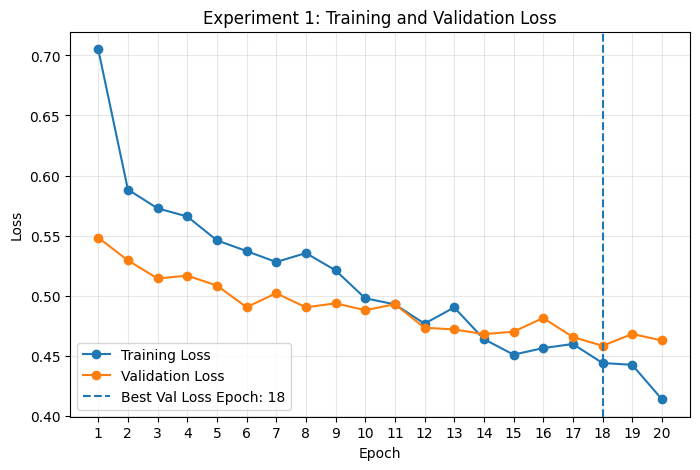

In [ ]:
# ============================================================
# SECTION 11.1: TRAINING AND VALIDATION LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    loss_values,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_loss_values,
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    best_val_loss_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch: {best_val_loss_epoch}"
)

plt.title("Experiment 1: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

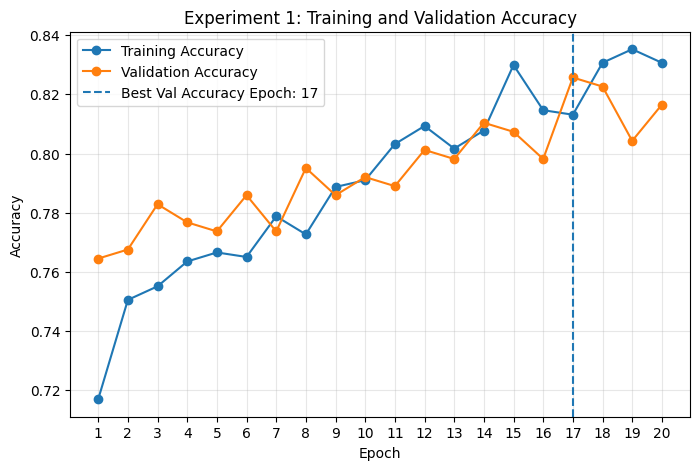

In [ ]:
# ============================================================
# SECTION 11.2: TRAINING AND VALIDATION ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    accuracy_values,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracy_values,
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    best_val_accuracy_epoch,
    linestyle="--",
    label=f"Best Val Accuracy Epoch: {best_val_accuracy_epoch}"
)

plt.title("Experiment 1: Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# Section 12 — Evaluate the Experiment 1 Model

The trained model is evaluated on the unchanged validation set using overall and class-level metrics.

Evaluation includes:

- Accuracy
- Per-class precision
- Per-class recall
- Per-class F1-score
- Macro average
- Micro average
- Weighted average
- Confusion matrix

<br>

> **Research note:** Accuracy alone is insufficient for this dataset because the class distribution is imbalanced.

In [ ]:
# ============================================================
# SECTION 12: BASIC VALIDATION EVALUATION
# ============================================================

val_loss, val_accuracy = exp1_model.evaluate(val_ds, verbose=1)

print("Experiment 1 Validation Results")
print("-" * 45)
print(f"Validation Loss    : {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.8226 - loss: 0.4583
Experiment 1 Validation Results
---------------------------------------------
Validation Loss    : 0.4583
Validation Accuracy: 0.8226


In [ ]:
# ============================================================
# SECTION 12.1: EXTRACT TRUE LABELS AND MODEL PREDICTIONS
# ============================================================

y_true = []
y_pred = []
y_pred_probabilities = []

for images, labels in val_ds:

    predictions = exp1_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)
    y_pred_probabilities.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_probabilities = np.array(y_pred_probabilities)

print("Number of validation samples :", len(y_true))
print("Number of predictions        :", len(y_pred))
print("Prediction probability shape :", y_pred_probabilities.shape)

Prediction extraction complete.
Number of validation samples : 327
Number of predictions        : 327
Prediction probability shape : (327, 3)


## Section 12.2 — Classification Report

The classification report provides class-level precision, recall, F1-score, and support. This is essential for checking whether the baseline model performs consistently across all CDT categories.

In [ ]:
# ============================================================
# SECTION 12.2: CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("Experiment 1 Classification Report")
print("-" * 45)
print(report)

Experiment 1 Classification Report
---------------------------------------------
              precision    recall  f1-score   support

    Impaired     0.9091    0.6250    0.7407        16
        Mild     0.6000    0.3750    0.4615        64
      Normal     0.8514    0.9514    0.8987       247

    accuracy                         0.8226       327
   macro avg     0.7868    0.6505    0.7003       327
weighted avg     0.8051    0.8226    0.8054       327



In [ ]:
# ============================================================
# SECTION 12.3: MACRO, MICRO, AND WEIGHTED METRICS
# ============================================================

accuracy = accuracy_score(y_true, y_pred)

macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

micro_precision = precision_score(y_true, y_pred, average="micro", zero_division=0)
micro_recall = recall_score(y_true, y_pred, average="micro", zero_division=0)
micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)

weighted_precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
weighted_recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("Experiment 1 Summary Metrics")
print("-" * 45)
print(f"Accuracy           : {accuracy:.4f}")
print(f"Macro Precision    : {macro_precision:.4f}")
print(f"Macro Recall       : {macro_recall:.4f}")
print(f"Macro F1-score     : {macro_f1:.4f}")
print(f"Micro Precision    : {micro_precision:.4f}")
print(f"Micro Recall       : {micro_recall:.4f}")
print(f"Micro F1-score     : {micro_f1:.4f}")
print(f"Weighted Precision : {weighted_precision:.4f}")
print(f"Weighted Recall    : {weighted_recall:.4f}")
print(f"Weighted F1-score  : {weighted_f1:.4f}")

Experiment 1 Summary Metrics
---------------------------------------------
Accuracy           : 0.8226
Macro Precision    : 0.7868
Macro Recall       : 0.6505
Macro F1-score     : 0.7003
Micro Precision    : 0.8226
Micro Recall       : 0.8226
Micro F1-score     : 0.8226
Weighted Precision : 0.8051
Weighted Recall    : 0.8226
Weighted F1-score  : 0.8054


---
# Section 13 — Confusion Matrix

The confusion matrix shows how predictions are distributed across the actual classes.

For Experiment 1, it is used to examine whether the frozen baseline favors the majority class or meaningfully detects `Impaired` and `Mild` cases.

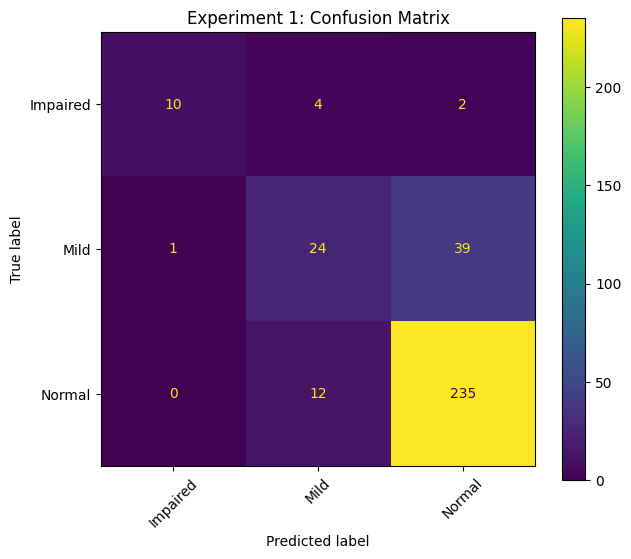

In [ ]:
# ============================================================
# SECTION 13: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45
)

plt.title("Experiment 1: Confusion Matrix")
plt.show()

In [ ]:
# ============================================================
# SECTION 13.1: CONFUSION MATRIX TABLE
# ============================================================

confusion_matrix_df = pd.DataFrame(
    cm,
    index=[f"Actual {name}" for name in class_names],
    columns=[f"Predicted {name}" for name in class_names]
)

confusion_matrix_df

,Predicted Impaired,Predicted Mild,Predicted Normal
Actual Impaired,10,4,2
Actual Mild,1,24,39
Actual Normal,0,12,235


---
# Section 14 — Result Tables

Clean result tables are prepared for documentation and comparison.

The first table presents per-class performance.  
The second table summarizes the overall Experiment 1 results.

In [ ]:
# ============================================================
# SECTION 14: PER-CLASS METRICS TABLE
# ============================================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    zero_division=0
)

per_class_metrics_df = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
})

per_class_metrics_df

,Class,Precision,Recall,F1-score,Support
0,Impaired,0.909091,0.625000,0.740741,16
1,Mild,0.600000,0.375000,0.461538,64
2,Normal,0.851449,0.951417,0.898662,247


In [ ]:
# ============================================================
# SECTION 14.1: EXPERIMENT 1 SUMMARY TABLE
# ============================================================

exp1_summary_df = pd.DataFrame({
    "Experiment": ["Experiment 1 - Frozen ResNet18 Baseline"],
    "Validation Loss": [val_loss],
    "Validation Accuracy": [accuracy],
    "Macro Precision": [macro_precision],
    "Macro Recall": [macro_recall],
    "Macro F1-score": [macro_f1],
    "Micro Precision": [micro_precision],
    "Micro Recall": [micro_recall],
    "Micro F1-score": [micro_f1],
    "Weighted Precision": [weighted_precision],
    "Weighted Recall": [weighted_recall],
    "Weighted F1-score": [weighted_f1],
    "Completed Epochs": [completed_epochs],
    "Best Val Loss": [best_val_loss],
    "Best Val Loss Epoch": [best_val_loss_epoch],
    "Best Val Accuracy": [best_val_accuracy],
    "Best Val Accuracy Epoch": [best_val_accuracy_epoch]
})

exp1_summary_df

,Experiment,Validation Loss,Validation Accuracy,Macro Precision,Macro Recall,Macro F1-score,Micro Precision,Micro Recall,Micro F1-score,Weighted Precision,Weighted Recall,Weighted F1-score,Completed Epochs,Best Val Loss,Best Val Loss Epoch,Best Val Accuracy,Best Val Accuracy Epoch
0,Experiment 1 - Frozen ResNet18 Baseline,0.45834,0.82263,0.786847,0.650472,0.700314,0.82263,0.82263,0.82263,0.805056,0.82263,0.805381,20,0.45834,18,0.825688,17


In [ ]:
# ============================================================
# SECTION 14.2: SAVE RESULT TABLES
# ============================================================

per_class_metrics_df.to_csv(PER_CLASS_CSV_PATH, index=False)
exp1_summary_df.to_csv(SUMMARY_CSV_PATH, index=False)

print("Result tables saved successfully.")
print("Per-class metrics saved to:", PER_CLASS_CSV_PATH)
print("Summary metrics saved to  :", SUMMARY_CSV_PATH)

Result tables saved successfully.
Per-class metrics saved to: /content/drive/MyDrive/Colab Notebooks/models/exp1_per_class_metrics.csv
Summary metrics saved to  : /content/drive/MyDrive/Colab Notebooks/models/exp1_summary_metrics.csv


---
# Section 15 — Save the Final Trained Model

The best model is saved automatically through `ModelCheckpoint`. The final in-memory model is also saved after training.

Because early stopping restores the best weights, the saved final model reflects the best validation-loss state reached during training.

In [ ]:
# ============================================================
# SECTION 15: SAVE FINAL MODEL
# ============================================================

exp1_model.save(FINAL_MODEL_PATH)

print("Best checkpoint model:", BEST_MODEL_PATH)
print("Final saved model    :", FINAL_MODEL_PATH)

Final Experiment 1 model saved successfully.
Best checkpoint model: /content/drive/MyDrive/Colab Notebooks/models/exp1_frozen_resnet18_best.keras
Final saved model    : /content/drive/MyDrive/Colab Notebooks/models/exp1_frozen_resnet18_final.keras


## Section 15.1 — Reload Check

The saved checkpoint is reloaded from Google Drive to confirm that the trained model can be reused without retraining.

In [ ]:
# ============================================================
# SECTION 15.1: SAVED MODEL RELOAD CHECK
# ============================================================

loaded_exp1_model = keras.models.load_model(BEST_MODEL_PATH)

loaded_val_loss, loaded_val_accuracy = loaded_exp1_model.evaluate(val_ds, verbose=0)

print(f"Reloaded model validation loss    : {loaded_val_loss:.4f}")
print(f"Reloaded model validation accuracy: {loaded_val_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 130 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Saved model reload check complete.
Reloaded model validation loss    : 0.4583
Reloaded model validation accuracy: 0.8226


---
# Section 16 — Experiment 1 Interpretation

The final interpretation summarizes Experiment 1 performance and explains how the frozen-backbone baseline behaved across the CDT classes.

## Experiment 1 Result Interpretation

### Overview

Experiment 1 used an ImageNet-pretrained ResNet18 backbone as a **fully frozen feature extractor**. The backbone weights were not updated during training, and only the custom classifier head learned from the CDT dataset.

This setup served as the baseline for comparing the effect of partial and full fine-tuning in the succeeding experiments.

---

### Overall Performance

| Metric | Experiment 1 Result |
|---|---:|
| Validation Accuracy | **0.8226** |
| Macro Precision | **0.7868** |
| Macro Recall | **0.6505** |
| Macro F1-score | **0.7003** |

Experiment 1 achieved reasonable baseline performance, showing that pretrained ResNet18 features were useful for CDT image classification even without backbone fine-tuning.

---

### Class-Level Observation

| Class | Recall |
|---|---:|
| Impaired | **0.6250** |
| Mild | **0.3750** |
| Normal | **0.9514** |

The model performed strongest on the `Normal` class and weakest on the `Mild` class. This suggests that frozen pretrained features were better at recognizing majority-class patterns but less effective at capturing more subtle CDT errors associated with mild impairment.

---

### Interpretation

The lower recall for `Mild` indicates that the frozen backbone had limited ability to adapt to CDT-specific visual patterns. Since only the classifier head was trained, the model relied entirely on the pretrained features extracted by ResNet18.

This result supports the need for Experiment 2 and Experiment 3, where deeper feature adaptation is introduced through partial and full fine-tuning.

---

### Key Takeaway

Experiment 1 establishes a strong baseline but shows limited class-balanced performance. Its results justify the use of fine-tuning strategies to improve detection of `Impaired` and `Mild` cases.

---
# Final Note

This notebook completed the fully frozen ResNet18 baseline experiment for Clock Drawing Test image classification.

The results from this experiment are intended for comparison with:

- **Experiment 2:** Partial 30% fine-tuning
- **Experiment 3:** Full fine-tuning with imbalance handling

Final model comparison should consider not only overall accuracy, but also macro F1-score and recall for the `Impaired` and `Mild` classes, since these metrics better reflect screening-sensitive performance.